# **Security incidents**

Dataset contains a comprehensive record of network security incidents, offering detailed insights into intrusion patterns and threat behaviour across an enterprise network. It provides information about the network traffic characteristics, connection endpoints and protocols, detection system outputs, device and user context, and response actions taken, to facilitate understanding of attack classification and triage in security operations. The goal is to try to predict the severity of the attack associated with a logged incident. The dataset has the following fields:

- Timestamp;

- Source IP Address;

- Destination IP Address;

- Source Port;

- Destination Port;

- Protocol;

- Packet Length;

- Packet Type;

- Traffic Type;

- Payload Data;

- Malware Indicators;

- Anomaly Scores;

- Alerts/Warnings;

- Attack Type;

- Attack Signature;

- Action Taken;

- User Information;

- Device Information;

- Network Segment;

- Geo-location Data;

- Proxy Information;

- Firewall Logs;

- IDS/IPS Alerts;

- Log Source;

## **Imports libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
sns.set_palette('viridis')
sns.color_palette(palette='viridis')

[(0.275191, 0.194905, 0.496005),
 (0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426),
 (0.626579, 0.854645, 0.223353)]

In [3]:
plt.set_loglevel('warning')

## **Load Dataset**

In [4]:
df = pd.read_csv("data.csv")

## **Inspect Dataset**

In [5]:
df.head()

,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,...,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,...,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  object 
 1   Source IP Address       40000 non-null  object 
 2   Destination IP Address  40000 non-null  object 
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  object 
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  object 
 8   Traffic Type            40000 non-null  object 
 9   Payload Data            40000 non-null  object 
 10  Malware Indicators      20000 non-null  object 
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  object 
 13  Attack Type             40000 non-null  object 
 14  Attack Signature        40000 non-null

In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

Timestamp was in the wrong format, so object -> datetime.

In [8]:
num_features = df.select_dtypes(include='number').columns.tolist()
num_features.append('Timestamp')
num_features.remove('Destination Port')
num_features.remove('Source Port')
print(f'Continuous features({len(num_features)}):')
print('Name\t\tMissing values')

for feature in num_features:
  print(feature,'\t',df[feature].isna().sum())

Continuous features(3):
Name		Missing values
Packet Length 	 0
Anomaly Scores 	 0
Timestamp 	 0


In [9]:
cat_features = df.loc[:,df.nunique()>2].select_dtypes(exclude='number').columns.tolist()
cat_features.remove('Timestamp')
cat_features.append('Destination Port')
cat_features.append('Source Port')
print(f'Categorical features({len(cat_features)}):')
print('Name','Unique','Missing values',sep='\t\t')

for feature in cat_features:
  print(feature,df[feature].nunique(),df[feature].isna().sum(),sep='\t')

Categorical features(15):
Name		Unique		Missing values
Source IP Address	40000	0
Destination IP Address	40000	0
Protocol	3	0
Traffic Type	3	0
Payload Data	40000	0
Attack Type	3	0
Action Taken	3	0
Severity Level	3	0
User Information	32389	0
Device Information	32104	0
Network Segment	3	0
Geo-location Data	8723	0
Proxy Information	20148	19851
Destination Port	29895	0
Source Port	29761	0


In [10]:
bin_cols = df.loc[:,df.nunique()<=2].select_dtypes(exclude='number').columns.tolist()
print(f'Binary features({len(bin_cols)}):\n')

for col in bin_cols:
  print('Feature', col, 'has', df[col].isna().sum(), 'missing values,',
        'and the following unique values:',df[col].unique(),'\n')

Binary features(7):

Feature Packet Type has 0 missing values, and the following unique values: ['Data' 'Control'] 

Feature Malware Indicators has 20000 missing values, and the following unique values: ['IoC Detected' nan] 

Feature Alerts/Warnings has 20067 missing values, and the following unique values: [nan 'Alert Triggered'] 

Feature Attack Signature has 0 missing values, and the following unique values: ['Known Pattern B' 'Known Pattern A'] 

Feature Firewall Logs has 19961 missing values, and the following unique values: ['Log Data' nan] 

Feature IDS/IPS Alerts has 20050 missing values, and the following unique values: [nan 'Alert Data'] 

Feature Log Source has 0 missing values, and the following unique values: ['Server' 'Firewall'] 



There are 25 features in total.

*   The 3 continuous features have no missing data, which is great.

*   The 15 categorical ones have mostly low-cardinality, however some exceptions exist - such as IP Addresses. BUT, they need feature engineering because in this state they cannot be used for any encoding. The only with missing values is Proxy Information,but it also has all the values unique, so it will also be used in feature engineering.
    *    Although the ports are numerical values, 8080 port is not somehow worse than port 8081 or 9283, so they are also categorical features, though with high cardinality.

*   The 7 binary features are captivating. The majority of the features with missing values(4) are there. In fact, they just represent that some event has occurred, be it a firewall or an alert.


In [11]:
df[num_features].describe()

,Packet Length,Anomaly Scores,Timestamp
count,40000.000000,40000.000000,40000
mean,781.452725,50.113473,2021-11-22 06:17:52.200800256
min,64.000000,0.000000,2020-01-01 00:43:27
25%,420.000000,25.150000,2020-12-12 19:56:28.500000
50%,782.000000,50.345000,2021-11-21 18:12:51
75%,1143.000000,75.030000,2022-10-30 08:48:10.500000
max,1500.000000,100.000000,2023-10-11 19:34:23
std,416.044192,28.853598,NaN


It is a more detailed description of continuous features.

In the dataset provided, there are attacks from 2020 to 2023.
The anomaly scores might be uniformly distributed(but it needs further investigation).
The packet length varies from 64 to 1500.

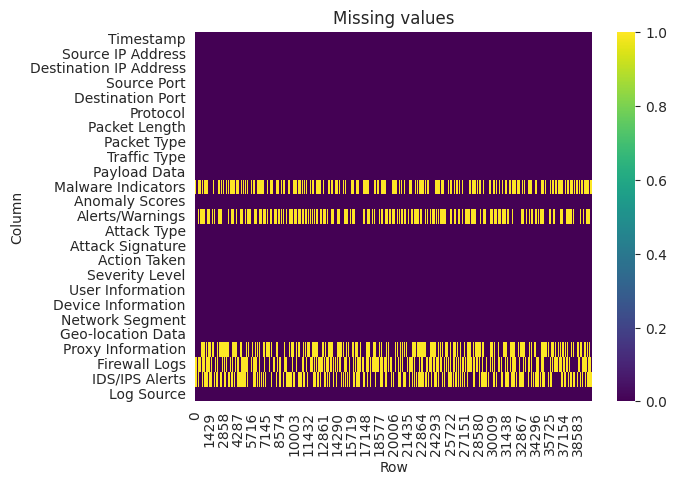

In [12]:
sns.heatmap(df.isnull().T, cmap='viridis', square=False, norm=None)
plt.title('Missing values')
plt.xlabel('Row')
plt.ylabel('Column')
plt.show()

The missing data doesn't have a certain pattern. Actually, it only shows that there were malware indicators/alerts/logs, e.t.c..

## **Data Analysis**

### Severity Level

In [13]:
severity_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Severity_Level_Num'] = df['Severity Level'].map(severity_map)

Lets' try to use mapping on Severity Level, because it actually have sense - low < medium < high.

### Numerical Features

In [14]:
num_features_1 = num_features.copy()
num_features_1.remove('Timestamp')

Timestamp will be considered separately.

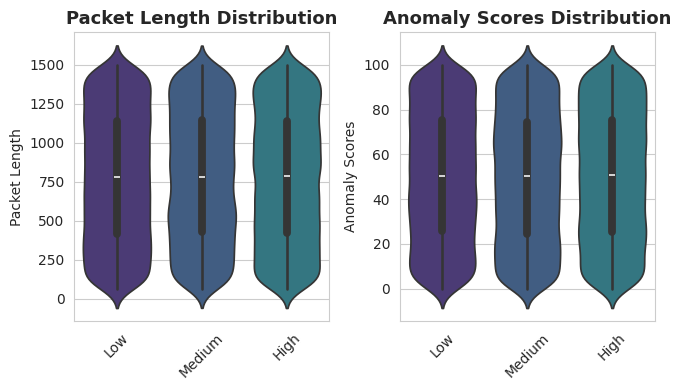

In [15]:
n_cols = 3
nrows = int(np.ceil(len(num_features_1) / n_cols))

fig, axes = plt.subplots(nrows, n_cols, figsize=(10, 4))
axes = axes.flatten()

for i, feature in enumerate(num_features_1):
  sns.violinplot(data=df, x='Severity Level', y=feature, hue='Severity Level', inner='box', ax=axes[i])
  axes[i].set_title(feature)
  axes[i].tick_params(axis='x', rotation=45)
  axes[i].set_title(f'{feature} Distribution', fontsize=13, fontweight='bold')
  axes[i].set_xlabel('')

[fig.delaxes(axes[j]) for j in range(i + 1, len(axes))]

plt.tight_layout()
plt.show()

There are no major differences in severity level among attacks based on packet length and anomaly score.

### Timestamp

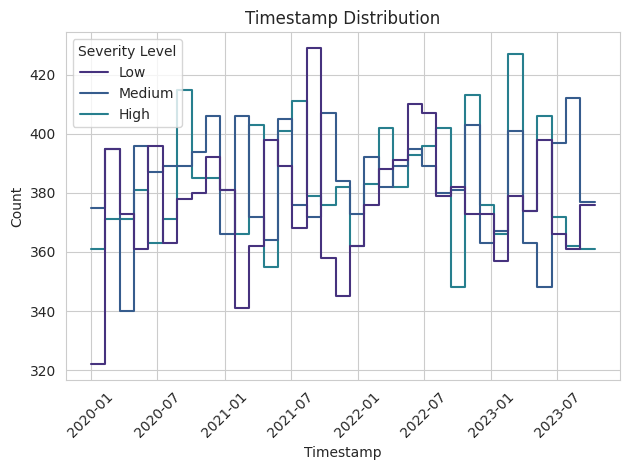

In [16]:
sns.histplot(data=df, x='Timestamp', hue='Severity Level', element='step', fill=False)
plt.title('Timestamp Distribution')
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

At least on this histplot, there seems to be no certain pattern in timestamp and the severity level of the attack occured. BUT let's dive deeper - maybe the day of the week or the hour matter?

In [17]:
df['Timestamp']

,Timestamp
0,2023-05-30 06:33:58
1,2020-08-26 07:08:30
2,2022-11-13 08:23:25
3,2023-07-02 10:38:46
4,2023-07-16 13:11:07
...,...
39995,2023-05-26 14:08:42
39996,2023-03-27 00:38:27
39997,2022-03-31 01:45:49
39998,2023-09-22 18:32:38


In [18]:
df['day_of_week'] = df['Timestamp'].dt.dayofweek
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

df['hour'] = df['Timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

Some feature engineering. sin and cos applied because 1,2,3...7 goes back to 1.

In [19]:
def time_bucket(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Midday'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['hour'].apply(time_bucket)

In [20]:
new_features = ['day_of_week', 'hour', 'Time_of_Day']
for feature in new_features:
  print(feature)
  print(pd.crosstab(df[feature], df['Severity Level'], normalize='index').round(2))
  print()

day_of_week
Severity Level  High   Low  Medium
day_of_week                       
0               0.33  0.33    0.34
1               0.33  0.34    0.33
2               0.32  0.34    0.34
3               0.34  0.31    0.34
4               0.33  0.34    0.33
5               0.34  0.32    0.34
6               0.34  0.33    0.33

hour
Severity Level  High   Low  Medium
hour                              
0               0.31  0.32    0.36
1               0.34  0.34    0.32
2               0.34  0.34    0.32
3               0.35  0.31    0.35
4               0.34  0.33    0.33
5               0.34  0.34    0.32
6               0.33  0.35    0.33
7               0.35  0.32    0.33
8               0.32  0.34    0.34
9               0.33  0.33    0.34
10              0.31  0.36    0.33
11              0.32  0.33    0.35
12              0.33  0.32    0.35
13              0.33  0.34    0.32
14              0.32  0.36    0.32
15              0.35  0.31    0.34
16              0.34  0.32    0.35
17

Again no correlation. Attacks of each severity level have the same probability to occur. It means that there is no pattern in time the attack occured. Drop.

Moreover, timestamp is not useful - why should it matter when it occured? It can not only act as noise, but also cause data leakage.

In [21]:
new_features = ['day_of_week', 'hour', 'day_of_week_sin', 'hour_sin',
                'day_of_week_cos', 'hour_cos', 'Time_of_Day', 'Timestamp']
df.drop(new_features, axis=1, inplace=True)

### Categorical features with low cardinality

In [22]:
low_card_cat_features = df.loc[:,df.nunique() < 10].select_dtypes(exclude='number').columns.tolist()

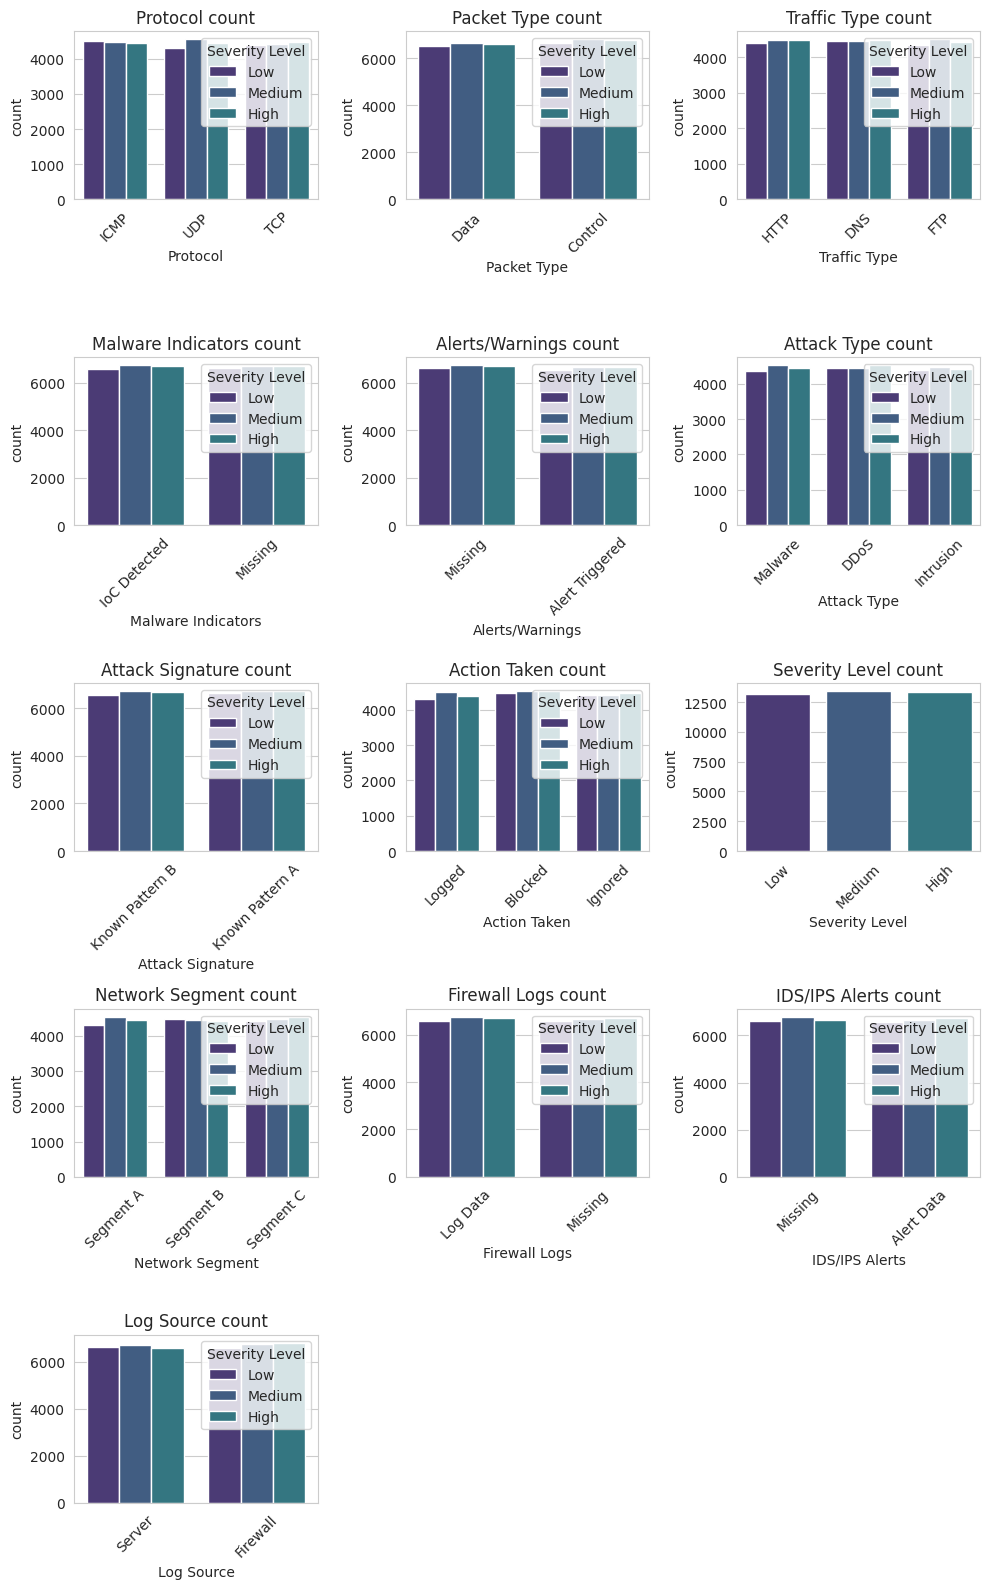

In [23]:
ncols = 3
nrows = int(np.ceil(len(low_card_cat_features) / n_cols))

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 16))
axes = axes.flatten()
data = df[low_card_cat_features].copy()
data = data.fillna('Missing')

for i, feature in enumerate(low_card_cat_features):
  sns.countplot(data=data, x=feature, hue='Severity Level', ax=axes[i])
  axes[i].set_title(f'{feature} count')
  axes[i].tick_params(axis='x', rotation=45)

[fig.delaxes(axes[j]) for j in range(i + 1, len(axes))]

plt.tight_layout()
plt.show()

In [24]:
for col in low_card_cat_features:
    print(col)
    print(pd.crosstab(data[col], data['Severity Level'], normalize='index').round(2))
    print()

Protocol
Severity Level  High   Low  Medium
Protocol                          
ICMP            0.33  0.34    0.33
TCP             0.34  0.33    0.33
UDP             0.33  0.32    0.34

Packet Type
Severity Level  High   Low  Medium
Packet Type                       
Control         0.33  0.33    0.34
Data            0.33  0.33    0.34

Traffic Type
Severity Level  High   Low  Medium
Traffic Type                      
DNS             0.34  0.33    0.33
FTP             0.33  0.33    0.34
HTTP            0.33  0.33    0.34

Malware Indicators
Severity Level      High   Low  Medium
Malware Indicators                    
IoC Detected        0.33  0.33    0.34
Missing             0.33  0.33    0.33

Alerts/Warnings
Severity Level   High   Low  Medium
Alerts/Warnings                    
Alert Triggered  0.34  0.33    0.34
Missing          0.33  0.33    0.34

Attack Type
Severity Level  High   Low  Medium
Attack Type                       
DDoS            0.34  0.33    0.33
Intrusion       0.3

There are around 33% of each severity level, so no SMOTE needed.
Through all the categories, there are no significant changes in distribution of Severity Level among different categories.

### Binary features

Lets' just map to 0/1 all the binary features

In [25]:
for col in bin_cols:
    if col in df.columns:
        cats = df[col].dropna().unique()
        if len(cats) == 2:
            df[col] = df[col].map({cats[0]: 0, cats[1]: 1})
        else:
            df[col] = df[col].notna().astype(int)

In [26]:
df.corr(numeric_only=True)['Severity_Level_Num'].sort_values(ascending=False)

,Severity_Level_Num
Severity_Level_Num,1.000000
Log Source,0.008647
Destination Port,0.003424
IDS/IPS Alerts,0.002684
Malware Indicators,0.001810
Packet Type,0.001001
Anomaly Scores,0.000936
Packet Length,0.000874
Alerts/Warnings,0.000849
Firewall Logs,0.000632


As shown by the bar plots before and the table above, they don't have any correlation at all.

### IP Address features

In [27]:
import ipaddress

In [28]:
def classify_ip(ip_str):
    if pd.isna(ip_str):
        return 'No Proxy'
    try:
        ip = ipaddress.ip_address(ip_str)
        return 'Private' if ip.is_private else 'Public'
    except ValueError:
        return 'Invalid'

Lets' map IP Addresses by their type - whether they are private or public.

#### Proxy

In [29]:
df['Proxy Information'].nunique()

20148

Too many unique ones, each one appears ~2 times, useless

In [30]:
df['Proxy Engineering'] = df['Proxy Information'].map(classify_ip)

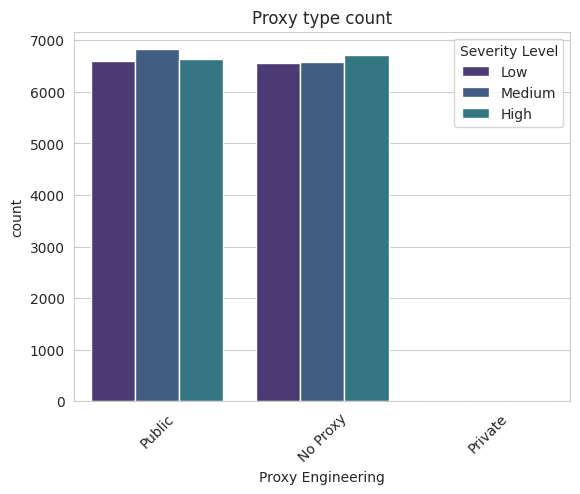

In [31]:
sns.countplot(data=df, x='Proxy Engineering', hue='Severity Level')
plt.title('Proxy type count')
plt.tick_params(axis='x', rotation=45)

Ehm.... Maybe there are no private proxies?

In [32]:
len(df[df['Proxy Engineering'] == 'Private'])

84

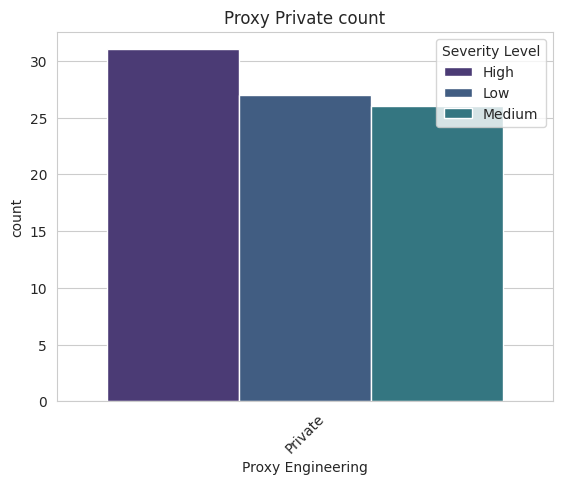

In [33]:
sns.countplot(data=df[df['Proxy Engineering'] == 'Private'], x='Proxy Engineering', hue='Severity Level')
plt.title('Proxy Private count')
plt.tick_params(axis='x', rotation=45)

It turns out there are almost no private networks used, so it is better to just map Proxy Information as proxy / no proxy.

In [34]:
df['Proxy Used'] = df['Proxy Information'].notna()

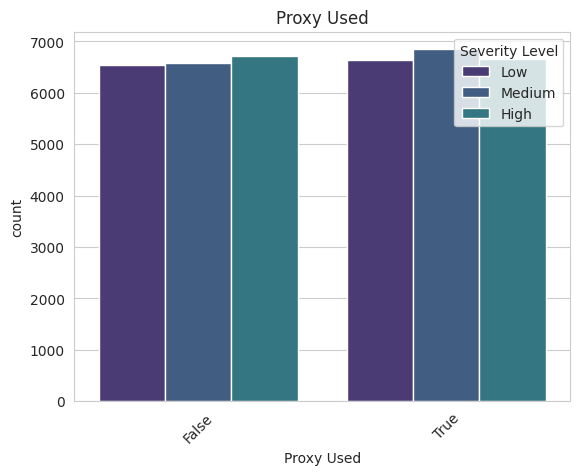

In [35]:
sns.countplot(data=df, x='Proxy Used', hue='Severity Level')
plt.title('Proxy Used')
plt.tick_params(axis='x', rotation=45)

In [36]:
df.drop(['Proxy Information', 'Proxy Engineering'], axis=1, inplace=True)

Now it looks better.

#### Destination & Source IP Addresses

In [37]:
df['Destination Type'] = df['Destination IP Address'].apply(classify_ip)
df['Source Type'] = df['Source IP Address'].apply(classify_ip)

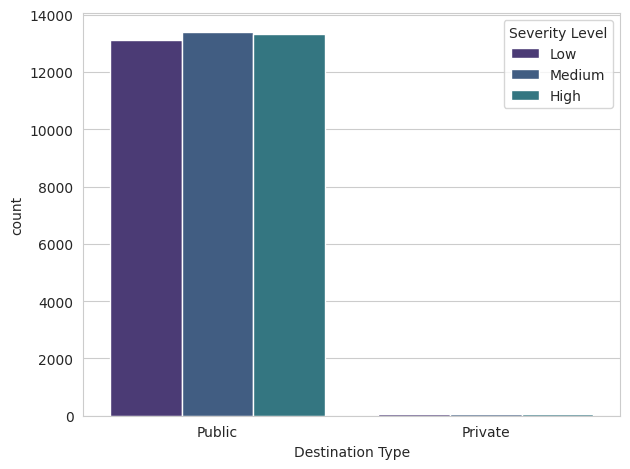

In [38]:
sns.countplot(df, x='Destination Type', hue='Severity Level')
plt.tight_layout()
plt.show()

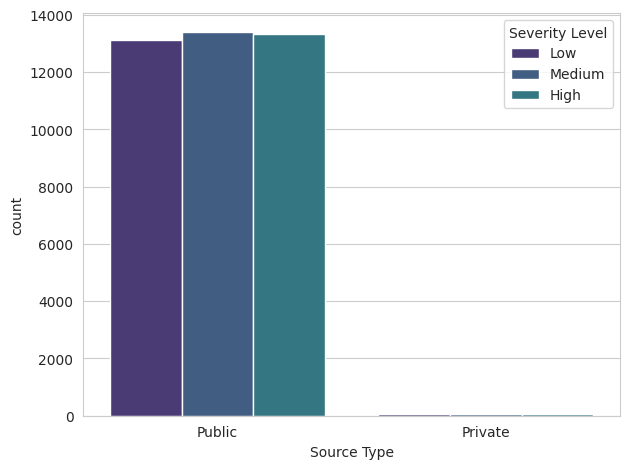

In [39]:
sns.countplot(df, x='Source Type', hue='Severity Level')
plt.tight_layout()
plt.show()

Turns out there are almost no private IP Addresses. Useless. If I try to take the first 8 bits, it will create too many features - 6 in total, and most probably there is no useful info. So better just drop it.

In [40]:
df.drop(['Source Type', 'Destination Type', 'Source IP Address', 'Destination IP Address'], axis=1, inplace=True)

### Geo-location Data

In [41]:
df['Geo-location Data']

,Geo-location Data
0,"Jamshedpur, Sikkim"
1,"Bilaspur, Nagaland"
2,"Bokaro, Rajasthan"
3,"Jaunpur, Rajasthan"
4,"Anantapur, Tripura"
...,...
39995,"Nashik, Manipur"
39996,"Vadodara, Mizoram"
39997,"Mahbubnagar, Himachal Pradesh"
39998,"Rourkela, Arunachal Pradesh"


In [42]:
df['Geo-location Data'].nunique()

8723

Geo-location data turns out to contain locations from India. 8723 are pretty many locations, better take just the states.

In [43]:
df['State'] = df['Geo-location Data'].str.split(', ').str[1]

In [44]:
df['State'].nunique()

28

28 are much less and should be much more useful.

In [45]:
print(pd.crosstab(df['State'], df['Severity Level'], normalize='index').round(2))

Severity Level     High   Low  Medium
State                                
Andhra Pradesh     0.33  0.34    0.33
Arunachal Pradesh  0.34  0.33    0.33
Assam              0.36  0.32    0.32
Bihar              0.36  0.32    0.32
Chhattisgarh       0.35  0.30    0.35
Goa                0.31  0.34    0.35
Gujarat            0.33  0.33    0.34
Haryana            0.35  0.33    0.33
Himachal Pradesh   0.35  0.32    0.33
Jharkhand          0.33  0.34    0.33
Karnataka          0.32  0.34    0.34
Kerala             0.34  0.34    0.33
Madhya Pradesh     0.36  0.32    0.32
Maharashtra        0.32  0.33    0.34
Manipur            0.33  0.32    0.34
Meghalaya          0.35  0.33    0.33
Mizoram            0.33  0.34    0.33
Nagaland           0.34  0.31    0.34
Odisha             0.31  0.32    0.37
Punjab             0.29  0.32    0.38
Rajasthan          0.33  0.32    0.35
Sikkim             0.33  0.32    0.35
Tamil Nadu         0.31  0.35    0.34
Telangana          0.36  0.33    0.32
Tripura     

But it turns out there is almost no difference. The range is 0.29 to 0.38. However, let's keep it for the time being.

### Payload Data

In [46]:
df['Payload Data'].nunique()

40000

In [47]:
samples = np.random.random_integers(0, 40_000, 10).tolist()

df['Payload Data'].iloc[samples]

/tmp/ipykernel_40809/861371779.py:1: DeprecationWarning: This function is deprecated. Please call randint(0, 40000 + 1) instead
  samples = np.random.random_integers(0, 40_000, 10).tolist()


,Payload Data
21240,Sunt doloremque vero porro corrupti. Ullam ven...
33190,Occaecati expedita unde culpa dolorem ut. Modi...
24413,Unde culpa fugiat. Facilis quia necessitatibus...
17163,Unde voluptate rerum repellat unde. Saepe haru...
7753,Cumque sunt totam. Qui voluptatem tenetur. Min...
5576,Molestias molestiae harum. Dicta perspiciatis ...
19331,Mollitia ipsam pariatur mollitia odio.\nCommod...
11343,Facere hic placeat sequi. Corporis error quia ...
27904,Doloremque minus repellat quo occaecati illo a...
34522,Tempore velit eum perferendis commodi. Volupta...


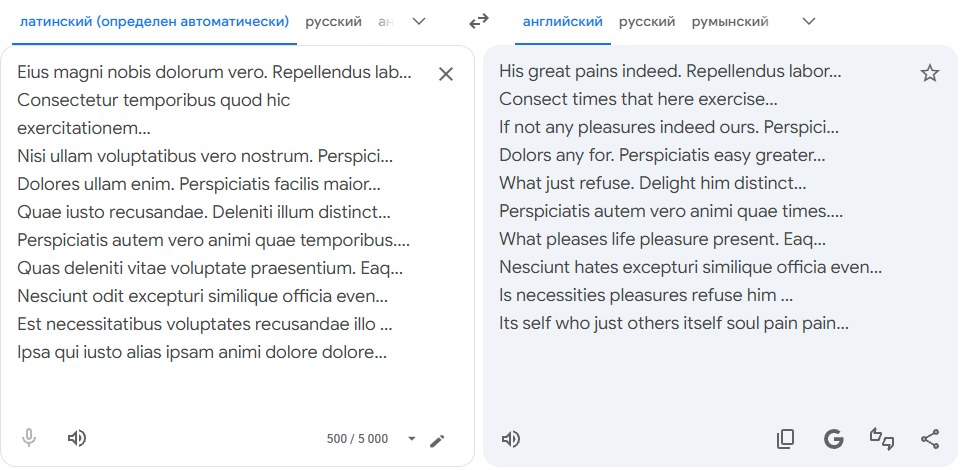

For this data, google translator considers it is Latin. I don't know this language, and taking into the consideration that all of the entries are different, it is practically useless for us.

In [48]:
df.drop('Payload Data', axis=1, inplace=True)

### Device Information

In [49]:
df['Device Information'].nunique()

32104

In [50]:
samples = np.random.random_integers(0, 40_000, 10).tolist()

df['Device Information'].iloc[samples]

/tmp/ipykernel_40809/2963710343.py:1: DeprecationWarning: This function is deprecated. Please call randint(0, 40000 + 1) instead
  samples = np.random.random_integers(0, 40_000, 10).tolist()


,Device Information
10232,Mozilla/5.0 (compatible; MSIE 5.0; Windows 95;...
26799,Opera/8.76.(Windows NT 6.1; tcy-IN) Presto/2.9...
4296,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...
29436,Mozilla/5.0 (Android 7.0; Mobile; rv:32.0) Gec...
39819,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_6_8 rv...
21039,Mozilla/5.0 (compatible; MSIE 8.0; Windows CE;...
7604,Mozilla/5.0 (Android 2.1; Mobile; rv:30.0) Gec...
34698,Mozilla/5.0 (Linux; Android 4.3) AppleWebKit/5...
6823,Mozilla/5.0 (compatible; MSIE 7.0; Windows 98;...
2,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...


Looks like there is written the browser used, and the OS of the device.

In [51]:
print(df['Device Information'][0])

Mozilla/5.0 (compatible; MSIE 8.0; Windows NT 6.2; Trident/5.0)


In [52]:
df['Device Information'].str.split('/').str[0].nunique()

2

In [53]:
df['Browser'] = df['Device Information'].str.split('/').str[0] == 'Mozilla'

In [54]:
print('Browser')
print(pd.crosstab(df['Browser'], df['Severity Level'], normalize='index').round(2))
print()

Browser
Severity Level  High   Low  Medium
Browser                           
False           0.35  0.33    0.32
True            0.33  0.33    0.34



In [55]:
df['Windows OS'] = df['Device Information'].str.contains('Windows')
df['iOS'] = df['Device Information'].str.contains('iPhone|Mac')
df['Linux OS'] = df['Device Information'].str.contains('Linux|Android')

In [56]:
df['Mobile'] = df['Device Information'].str.contains('Android|iPhone')

In [57]:
os_features = ['Windows OS', 'iOS', 'Linux OS', 'Mobile']

for os in os_features:
  print(os, df[os].astype('int64').sum())
  print(pd.crosstab(df[os], df['Severity Level'], normalize='index').round(2))
  print()

Windows OS 17953
Severity Level  High   Low  Medium
Windows OS                        
False           0.34  0.33    0.33
True            0.33  0.33    0.34

iOS 11587
Severity Level  High   Low  Medium
iOS                               
False           0.33  0.33    0.34
True            0.34  0.33    0.33

Linux OS 10460
Severity Level  High   Low  Medium
Linux OS                          
False           0.33  0.33    0.34
True            0.35  0.32    0.33

Mobile 7512
Severity Level  High   Low  Medium
Mobile                            
False           0.34  0.33    0.33
True            0.33  0.33    0.34



Both just OS or Mobile/Desktop doesn't provide any info... ~0.33..................

In [58]:
df.drop(['Device Information'], axis=1, inplace=True)

### Destination & Source ports

In [59]:
print(df['Destination Port'].nunique())
print(df['Source Port'].nunique())

29895
29761


In [60]:
import socket

common_ports = {
    20: 'FTP-data', 21: 'FTP', 22: 'SSH', 23: 'Telnet', 25: 'SMTP',
    53: 'DNS', 67: 'DHCP', 68: 'DHCP', 80: 'HTTP', 110: 'POP3',
    123: 'NTP', 143: 'IMAP', 161: 'SNMP', 443: 'HTTPS', 445: 'SMB',
    3306: 'MySQL', 3389: 'RDP', 5432: 'PostgreSQL', 8080: 'HTTP-alt',
}

def map_port(port):
    if port in common_ports:
        return common_ports[port]
    try:
        return socket.getservbyport(port)
    except OSError:
        return 'Other'

df['Source Port Service'] = df['Source Port'].apply(map_port)
df['Destination Port Service'] = df['Destination Port'].apply(map_port)

In [61]:
port_features = ['Source Port Service', 'Destination Port Service']

for port in port_features:
  print(port)
  print(pd.crosstab(df[port], df['Severity Level'], normalize='index').round(2))
  print()

Source Port Service
Severity Level       High   Low  Medium
Source Port Service                    
HTTP-alt             1.00  0.00    0.00
Other                0.33  0.33    0.34
RDP                  0.50  0.00    0.50

Destination Port Service
Severity Level            High   Low  Medium
Destination Port Service                    
HTTP-alt                  0.00  1.00    0.00
MySQL                     0.50  0.50    0.00
Other                     0.33  0.33    0.34
RDP                       1.00  0.00    0.00



Yeah, it does look like smth got good, but...

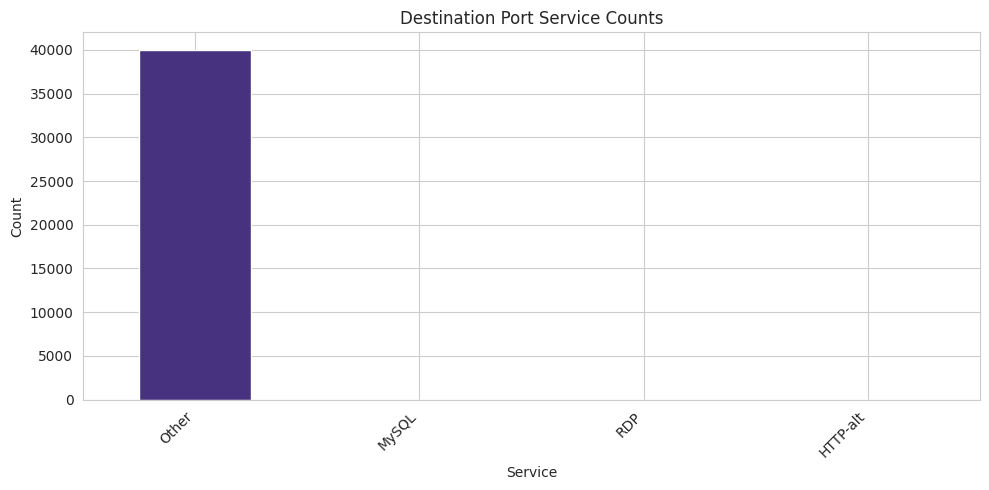

In [62]:
df['Destination Port Service'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Destination Port Service Counts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We also see this!!!

The cause of 'good' results we saw earlier is the lack of usage of such ports.

In [63]:
def port_bucket(port):
    if port < 1024:
        return 'Well-Known (0-1023)'
    elif port < 49152:
        return 'Registered (1024-49151)'
    else:
        return 'Ephemeral (49152-65535)'

df['Source Port Bucket'] = df['Source Port'].apply(port_bucket)
df['Destination Port Bucket'] = df['Destination Port'].apply(port_bucket)

Let's then try to map it by buckets.

In [64]:
df['Destination Port Bucket'].value_counts()
pd.crosstab(df['Destination Port Bucket'], df['Severity Level'], normalize='index').round(2)

Severity Level,High,Low,Medium
Destination Port Bucket,,,
Ephemeral (49152-65535),0.34,0.32,0.33
Registered (1024-49151),0.33,0.33,0.34


Same... NO USEFUL INFO AT ALL

### User Information

In [65]:
samples = np.random.random_integers(0, 40_000, 10).tolist()

df['User Information'].iloc[samples]

/tmp/ipykernel_40809/3846065968.py:1: DeprecationWarning: This function is deprecated. Please call randint(0, 40000 + 1) instead
  samples = np.random.random_integers(0, 40_000, 10).tolist()


,User Information
30245,Advika Dugar
36030,Vardaniya Barman
38986,Nehmat Dhillon
3470,Zara Kohli
7654,Pari Sinha
10915,Miraan Sabharwal
34851,Raunak Rama
19888,Arhaan Das
16985,Aradhya Samra
11142,Shaan Kapoor


In [66]:
df['User Information'].nunique()

32389

It turns out in User Information there are just Indian names, which rarely repeat -> useless.

In [67]:
df.drop('User Information', axis=1, inplace=True)

### Correlation check

In [68]:
df.columns

Index(['Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Malware Indicators', 'Anomaly Scores',
       'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken',
       'Severity Level', 'Network Segment', 'Geo-location Data',
       'Firewall Logs', 'IDS/IPS Alerts', 'Log Source', 'Severity_Level_Num',
       'Proxy Used', 'State', 'Browser', 'Windows OS', 'iOS', 'Linux OS',
       'Mobile', 'Source Port Service', 'Destination Port Service',
       'Source Port Bucket', 'Destination Port Bucket'],
      dtype='object')

In [69]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

In [70]:
mask = (df.nunique() < 4) & (df.nunique() > 2)
cat_cols = df.loc[:, mask].select_dtypes(exclude='number').columns.tolist()
cat_cols.remove('Severity Level')

dummies = pd.get_dummies(df[cat_cols]).astype(int)
df = pd.concat([df.drop(columns=cat_cols), dummies], axis=1)

In [71]:
df.corr(numeric_only=True)['Severity_Level_Num'].sort_values(ascending=False)

,Severity_Level_Num
Severity_Level_Num,1.000000
Linux OS,0.015006
Log Source,0.008647
Source Port Service_HTTP-alt,0.008634
Protocol_UDP,0.006306
Network Segment_Segment A,0.005405
Source Port Service_RDP,0.004295
Destination Port,0.003424
IDS/IPS Alerts,0.002684
Action Taken_Logged,0.002176


As proved throughout this notebook, almost no correlation. 😭😭😭

In [72]:
# correlation_matrix = df[morph_features].corr()

# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True, linewidths=1)
# plt.title('Morphological Feature Correlations')
# plt.tight_layout()
# plt.show()

# **Conclusion**

Actually, this dataset just looks like random data generated for fun... Features look interesting, but no matter how to analyse them, all of them have around the same expectance to appear, everywhere those ~33% 😭